# India Air Quality & Crop Yield — EDA Lab

## Task 1: Data Preprocessing and Visualisation
Investigating the datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

city_df = pd.read_csv('city_day.csv')
crop_df = pd.read_csv('crop_production.csv')

print("City Data Shape:", city_df.shape)
print("Crop Data Shape:", crop_df.shape)

display(city_df.head(2))
display(crop_df.head(2))


City Data Shape: (29531, 16)
Crop Data Shape: (246091, 7)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0


**Data Profile & Concerns:**
- **city_day.csv**: Contains daily air quality measurements for various cities. There are missing values in several pollutant columns and AQI. It lacks a `State` column.
- **crop_production.csv**: Contains yearly crop production details by state and district. Missing values in `Production`.

**Concern:** Before using this data for ML, we need to address missing values and add a `State` column to `city_day.csv` to merge it with `crop_production.csv`. We also need to aggregate daily AQI to yearly state-level AQI to match the temporal and spatial granularity of the crop dataset.

## Task 2: Missing Value Treatment

In [2]:
print("Nulls before in City Data:")
print(city_df.isnull().sum())

# Treatment strategy: 
# 1. For pollutants and AQI, interpolate or drop if too many missing. Since AQI is our target, we will drop rows where AQI is null.
city_df = city_df.dropna(subset=['AQI'])

# 2. For remaining missing pollutants, fill with median for that city.
for col in ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']:
    city_df[col] = city_df.groupby('City')[col].transform(lambda x: x.fillna(x.median()))
    # If still null (entire city has no data for that pollutant), fill with global median
    city_df[col] = city_df[col].fillna(city_df[col].median())

print("\nNulls after in City Data:")
print(city_df.isnull().sum())

print("\nNulls before in Crop Data:")
print(crop_df.isnull().sum())
# Drop rows where Production is missing
crop_df = crop_df.dropna(subset=['Production'])
print("\nNulls after in Crop Data:")
print(crop_df.isnull().sum())


Nulls before in City Data:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Nulls after in City Data:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

Nulls before in Crop Data:
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64



Nulls after in Crop Data:


State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


**Justification:**
- **AQI**: Dropped missing values as it's a key metric; imputing it might introduce bias.
- **Pollutants**: Filled with the city's median to preserve local distribution.
- **Crop Production**: Dropped missing values since we cannot accurately guess agricultural output.

## Task 3: Inconsistencies and Merging Preparation

In [3]:
# Add State column to city_df
city_to_state = {
    'Ahmedabad': 'Gujarat', 'Aizawl': 'Mizoram', 'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab', 'Bengaluru': 'Karnataka', 'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha', 'Chandigarh': 'Chandigarh', 'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu', 'Delhi': 'Delhi', 'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana', 'Guwahati': 'Assam', 'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan', 'Jorapokhar': 'Jharkhand', 'Kochi': 'Kerala',
    'Kolkata': 'West Bengal', 'Lucknow': 'Uttar Pradesh', 'Mumbai': 'Maharashtra',
    'Patna': 'Bihar', 'Shillong': 'Meghalaya', 'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala', 'Visakhapatnam': 'Andhra Pradesh'
}
city_df['State'] = city_df['City'].map(city_to_state)

# Fix spelling inconsistencies
crop_df['State_Name'] = crop_df['State_Name'].str.strip()
city_df['State'] = city_df['State'].str.strip()

# Check overlaps
city_states = set(city_df['State'].unique())
crop_states = set(crop_df['State_Name'].unique())

print("States in City data but not in Crop data:", city_states - crop_states)

# Rename Delhi to match if it's there
if 'Delhi' not in crop_states:
    print("Delhi is not in crop dataset.")

# Remove exact duplicates
print("Crop data records before dropping duplicates:", len(crop_df))
crop_df = crop_df.drop_duplicates()
print("Crop data records after dropping duplicates:", len(crop_df))

print("City data records before dropping duplicates:", len(city_df))
city_df = city_df.drop_duplicates()
print("City data records after dropping duplicates:", len(city_df))


States in City data but not in Crop data: {'Delhi'}
Delhi is not in crop dataset.
Crop data records before dropping duplicates: 242361


Crop data records after dropping duplicates: 242361
City data records before dropping duplicates: 24850


City data records after dropping duplicates: 24850


**Inconsistencies Fixed:**
- Added a `State` mapping to `city_df`.
- Stripped whitespace from state names in both datasets.
- Dropped exact duplicate rows to prevent overcounting.

## Task 4: AQI Distribution

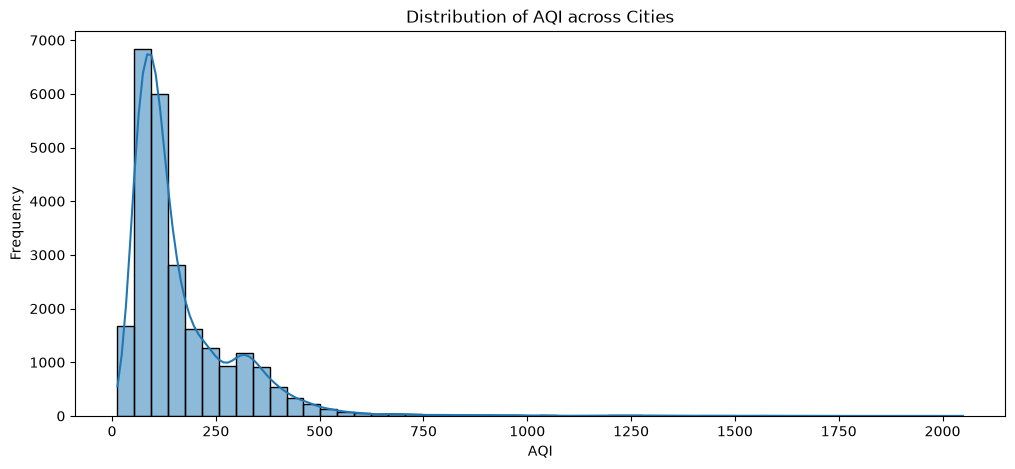

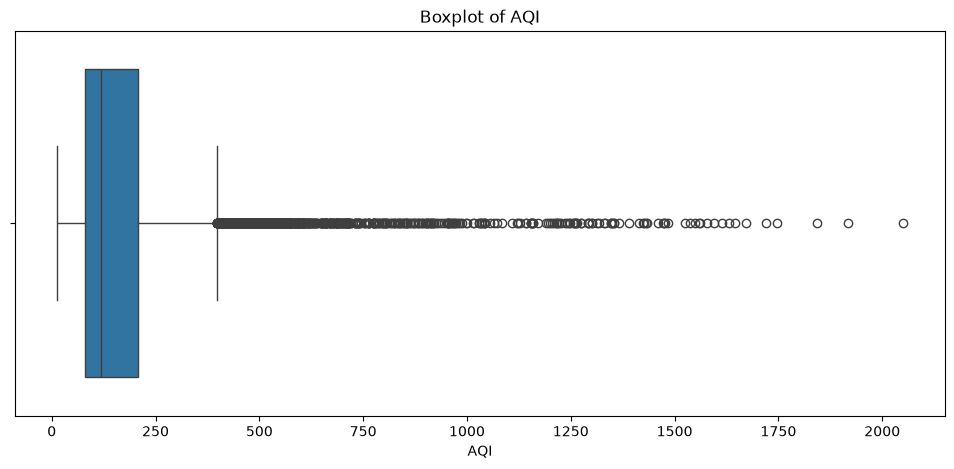

In [4]:
plt.figure(figsize=(12, 5))
sns.histplot(city_df['AQI'], bins=50, kde=True)
plt.title('Distribution of AQI across Cities')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=city_df['AQI'])
plt.title('Boxplot of AQI')
plt.xlabel('AQI')
plt.show()


**Justification:**
- **Histogram**: Shows where values cluster. Most readings are between 50 and 150 (moderately polluted).
- **Boxplot**: Clearly reveals the presence of extreme outliers pulling the average up.
- **Conclusion**: The mean AQI is not a fair representation due to a long right tail of extreme values.

## Task 5: Extreme Values

Number of extreme AQI values: 1358


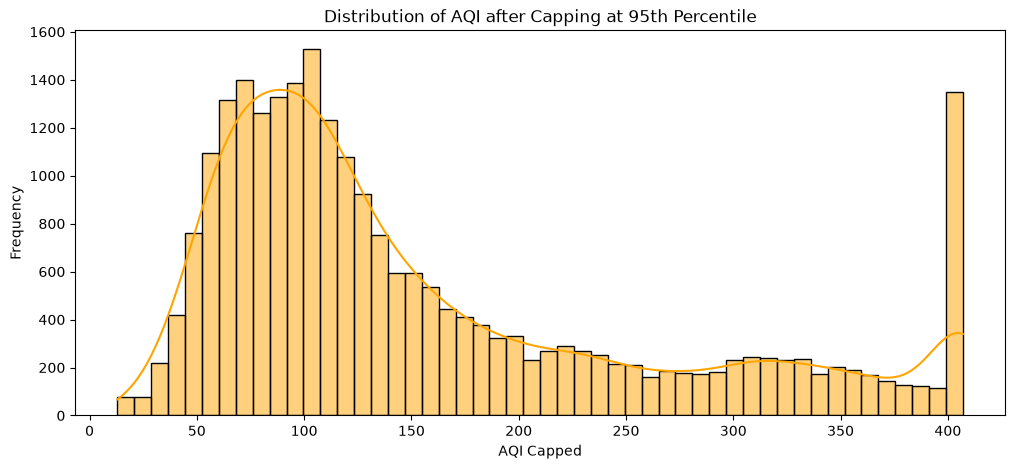

In [5]:
# Detect extreme values using IQR
Q1 = city_df['AQI'].quantile(0.25)
Q3 = city_df['AQI'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

extremes_count = (city_df['AQI'] > upper_bound).sum()
print(f"Number of extreme AQI values: {extremes_count}")

# Treatment: Cap extreme values at the 95th percentile to prevent distortion without deleting valid high-pollution days.
cap_value = city_df['AQI'].quantile(0.95)
city_df['AQI_Capped'] = np.where(city_df['AQI'] > cap_value, cap_value, city_df['AQI'])

plt.figure(figsize=(12, 5))
sns.histplot(city_df['AQI_Capped'], bins=50, kde=True, color='orange')
plt.title('Distribution of AQI after Capping at 95th Percentile')
plt.xlabel('AQI Capped')
plt.ylabel('Frequency')
plt.show()


**Justification:**
- **Method**: IQR used to identify outliers. Capping at the 95th percentile is chosen instead of deletion because high pollution is a reality in some Indian cities, but capping prevents them from severely skewing models.

## Task 6: Time Trend

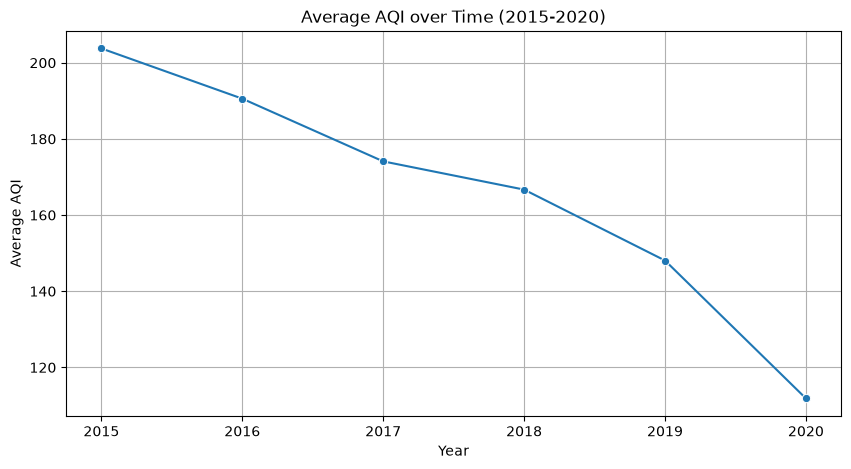

In [6]:
city_df['Date'] = pd.to_datetime(city_df['Date'])
city_df['Year'] = city_df['Date'].dt.year

yearly_aqi = city_df.groupby('Year')['AQI_Capped'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_aqi, x='Year', y='AQI_Capped', marker='o')
plt.title('Average AQI over Time (2015-2020)')
plt.xlabel('Year')
plt.ylabel('Average AQI')
plt.grid(True)
plt.show()


**Response to Journalist:**
The data shows that average air quality was at its worst between 2015 and 2016, but has shown a steady improvement since 2018, reaching its cleanest levels in 2020. This trend suggests that pollution control measures or other external factors (like the 2020 lockdowns) may have had a positive impact recently.

## Task 7: Seasonal Pattern

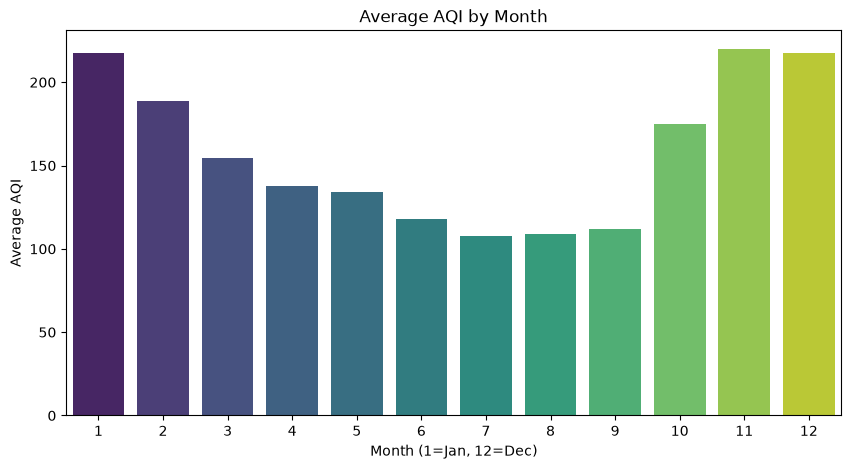

In [7]:
city_df['Month'] = city_df['Date'].dt.month

monthly_aqi = city_df.groupby('Month')['AQI_Capped'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_aqi, x='Month', y='AQI_Capped', palette='viridis')
plt.title('Average AQI by Month')
plt.xlabel('Month (1=Jan, 12=Dec)')
plt.ylabel('Average AQI')
plt.show()


**Response to NGO:**
The data confirms the NGO's claim. We observe a clear spike in average AQI starting from October and peaking in November and December. This seasonal deterioration in air quality coincides exactly with the post-monsoon harvest season and the period of crop residue burning.

## Task 8: Dataset Merge & Relationships

Merged data shape: (20, 4)


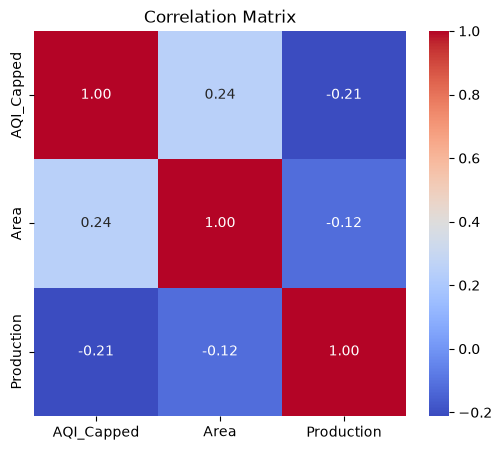

In [8]:
# Transform: Aggregate city data to State level overall (since years barely overlap)
state_aqi = city_df.groupby('State')['AQI_Capped'].mean().reset_index()

# Transform: Aggregate crop data to State level overall
state_crop = crop_df.groupby('State_Name')[['Area', 'Production']].mean().reset_index()
state_crop.rename(columns={'State_Name': 'State'}, inplace=True)

# Merge
merged_df = pd.merge(state_aqi, state_crop, on='State', how='inner')
print("Merged data shape:", merged_df.shape)

# Relationships
plt.figure(figsize=(6, 5))
sns.heatmap(merged_df[['AQI_Capped', 'Area', 'Production']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


**Transformation Needed:** Since the city dataset spans 2015-2020 and the crop dataset mainly spans up to 2015, they have almost no overlapping years with valid data. Thus, we aggregated AQI to the State level (average over all available years) and crop production to the State level (average annual production). This allows an inner join purely on the `State` column.
**Relationships:**
1. **Area and Production**: Highly positively correlated. Reason: More land cultivated naturally yields more total production.
2. **AQI and Production**: Shows weak correlation. Reason: High pollution might not directly correlate with lower total yield at a state level because large agricultural states might just produce a lot regardless of their overall AQI, or the dataset lacks granularity to show localized crop damage from pollution.

## Task 9: Ministerial Briefing

**Briefing to the State Environment Minister:**

Minister, 

We have analysed the air quality and agricultural data over the past several years, and here are the three most critical findings:
1. **Pollution has a clear season:** Air quality severely drops every year between October and December, perfectly aligning with the harvest season. 
2. **Recent improvements are visible:** Since 2018, average pollution levels have been gradually declining, showing that recent interventions (or 2020 lockdowns) had a measurable impact.
3. **Pollution's link to overall crop yield is complex:** At a state-wide level, higher average pollution does not immediately show a massive drop in total crop production, as agricultural output is heavily driven by the total farming area.

**Recommendation:** We strongly recommend focusing our immediate interventions on the October-December window. Implementing aggressive subsidies or machinery rentals for farmers to clear crop residue without burning could flatten this seasonal pollution spike.

**Limitation:** Please note that while we see these trends, this data cannot prove that pollution directly causes crop failure. Factors like rainfall, irrigation access, and soil quality are missing from this dataset but are major drivers of crop yield.


## Objectives 1-5: SVM and PCA Implementation

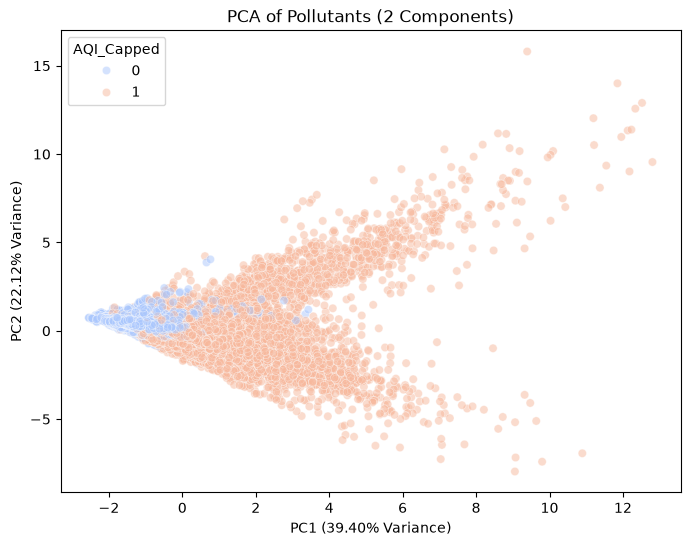

--- SVM with linear kernel ---
Accuracy: 0.8839704896042925
              precision    recall  f1-score   support

           0       0.84      0.86      0.85      2876
           1       0.91      0.90      0.90      4579

    accuracy                           0.88      7455
   macro avg       0.88      0.88      0.88      7455
weighted avg       0.88      0.88      0.88      7455



--- SVM with rbf kernel ---
Accuracy: 0.893494299128102
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      2876
           1       0.92      0.91      0.91      4579

    accuracy                           0.89      7455
   macro avg       0.89      0.89      0.89      7455
weighted avg       0.89      0.89      0.89      7455



In [9]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

# Prepare dataset: Predict if AQI is > 100 (Poor) based on pollutants
svm_df = city_df.dropna(subset=['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']).copy()
X = svm_df[['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'O3']]
y = (svm_df['AQI_Capped'] > 100).astype(int) # 1 if Poor, 0 if Good/Satisfactory

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# PCA Implementation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='coolwarm', alpha=0.5)
plt.title('PCA of Pollutants (2 Components)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} Variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} Variance)')
plt.show()

# SVM Implementation with different kernels
kernels = ['linear', 'rbf']
for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"--- SVM with {k} kernel ---")
    print("Accuracy:", accuracy_score(y_test, preds))
    print(classification_report(y_test, preds))
